# Stage 3 -  the full metric suite over time

adds the other four — **HHI, Gini, Shannon
entropy, CR3/CR5** and computes all of them over time, giving you the complete
decentralisation picture across Bitcoin's history.

Everything runs on the cached `attributed_tags.parquet`, instantly and for free. That's the
payoff of caching Stage 1–2 — you'll re-run this dozens of times at zero cost.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

attr = pd.read_parquet("../data/derived/attributed_tags.parquet")
print(f"loaded {len(attr):,} attributed blocks (no query needed)")
attr.head(3)

loaded 954,375 attributed blocks (no query needed)


,height,timestamp,pool
0,0,2009-01-03 18:15:05+00:00,unknown
1,1,2009-01-09 02:54:25+00:00,unknown
2,2,2009-01-09 02:55:44+00:00,unknown


## The five metrics

Each takes a count-per-pool mapping and returns one number. Higher HHI / Gini /
CR mean *more* concentrated; higher Nakamoto / entropy mean *more* decentralised,
they move in opposite directions, which is a useful cross-check.

In [2]:
def _shares(counts):
    vals = np.asarray(list(counts.values()) if isinstance(counts, dict) else list(counts), dtype=float)
    vals = vals[vals > 0]
    total = vals.sum()
    return vals / total if total > 0 else vals

def nakamoto(counts):
    """Min entities jointly holding > 50%."""
    s = sorted(_shares(counts), reverse=True)
    cum = 0.0
    for i, x in enumerate(s, 1):
        cum += x
        if cum > 0.5:
            return i
    return len(s) if s else np.nan

def hhi(counts):
    """Sum of squared shares, range [1/n, 1]. (x10000 for the antitrust scale.)"""
    s = _shares(counts)
    return float(np.sum(s ** 2)) if len(s) else np.nan

def gini(counts):
    """Gini of the share distribution, range [0, 1-1/n]. Higher = more unequal."""
    s = np.sort(_shares(counts))
    n = len(s)
    if n == 0:
        return np.nan
    i = np.arange(1, n + 1)
    return float((2 * np.sum(i * s)) / (n * s.sum()) - (n + 1) / n)

def shannon_entropy(counts, base=2):
    """Entropy in bits, range [0, log2(n)]. Higher = more even = more decentralised."""
    s = _shares(counts)
    s = s[s > 0]
    return float(-np.sum(s * (np.log(s) / np.log(base)))) if len(s) else np.nan

def concentration_ratio(counts, k=3):
    """Combined share of the top k entities."""
    s = sorted(_shares(counts), reverse=True)
    return float(sum(s[:k]))

def all_metrics(counts):
    return {"nakamoto": nakamoto(counts), "hhi": hhi(counts), "gini": gini(counts),
            "shannon": shannon_entropy(counts), "cr3": concentration_ratio(counts, 3),
            "cr5": concentration_ratio(counts, 5)}

## Compute over time

`period` controls granularity (`"M"` monthly, `"W"` weekly, `"D"` daily) that's
the RQ3 knob. `unknown` controls how unattributed blocks are treated
(`"exclude"` = U2, `"single"` = U1), that's a D3 axis. We save the result in
long format, matching the `metrics_<config>.parquet` shape in your architecture.

In [3]:
def metrics_over_time(attributed, period="M", unknown="exclude"):
    df = attributed.copy()
    df["window"] = pd.to_datetime(df["timestamp"]).dt.to_period(period).dt.to_timestamp()
    if unknown == "exclude":
        df = df[df["pool"] != "unknown"]
    rows = []
    for win, g in df.groupby("window"):
        counts = g["pool"].value_counts().to_dict()
        for name, val in all_metrics(counts).items():
            rows.append({"window": win, "metric": name, "value": val,
                         "period": period, "unknown": unknown})
    return pd.DataFrame(rows)

mt = metrics_over_time(attr, period="M", unknown="exclude")
mt.to_parquet("../data/derived/metrics_tags_monthly.parquet")
print(f"{len(mt):,} rows across {mt['metric'].nunique()} metrics and "
      f"{mt['window'].nunique()} months")
mt.head()

C:\Users\Nakis\AppData\Local\Temp\ipykernel_12088\1039405286.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["window"] = pd.to_datetime(df["timestamp"]).dt.to_period(period).dt.to_timestamp()


1,086 rows across 6 metrics and 181 months


,window,metric,value,period,unknown
0,2011-06-01,nakamoto,1.0,M,exclude
1,2011-06-01,hhi,1.0,M,exclude
2,2011-06-01,gini,0.0,M,exclude
3,2011-06-01,shannon,-0.0,M,exclude
4,2011-06-01,cr3,1.0,M,exclude


## The decentralisation picture

Six panels, one per metric, over the whole chain.
 Before pools widely adopted coinbase tags,
coverage is low, so each month's metric is computed over a handful of known pools
and swings wildly. That's the coverage→reliability link again:
the metric is only trustworthy where attribution is dense.

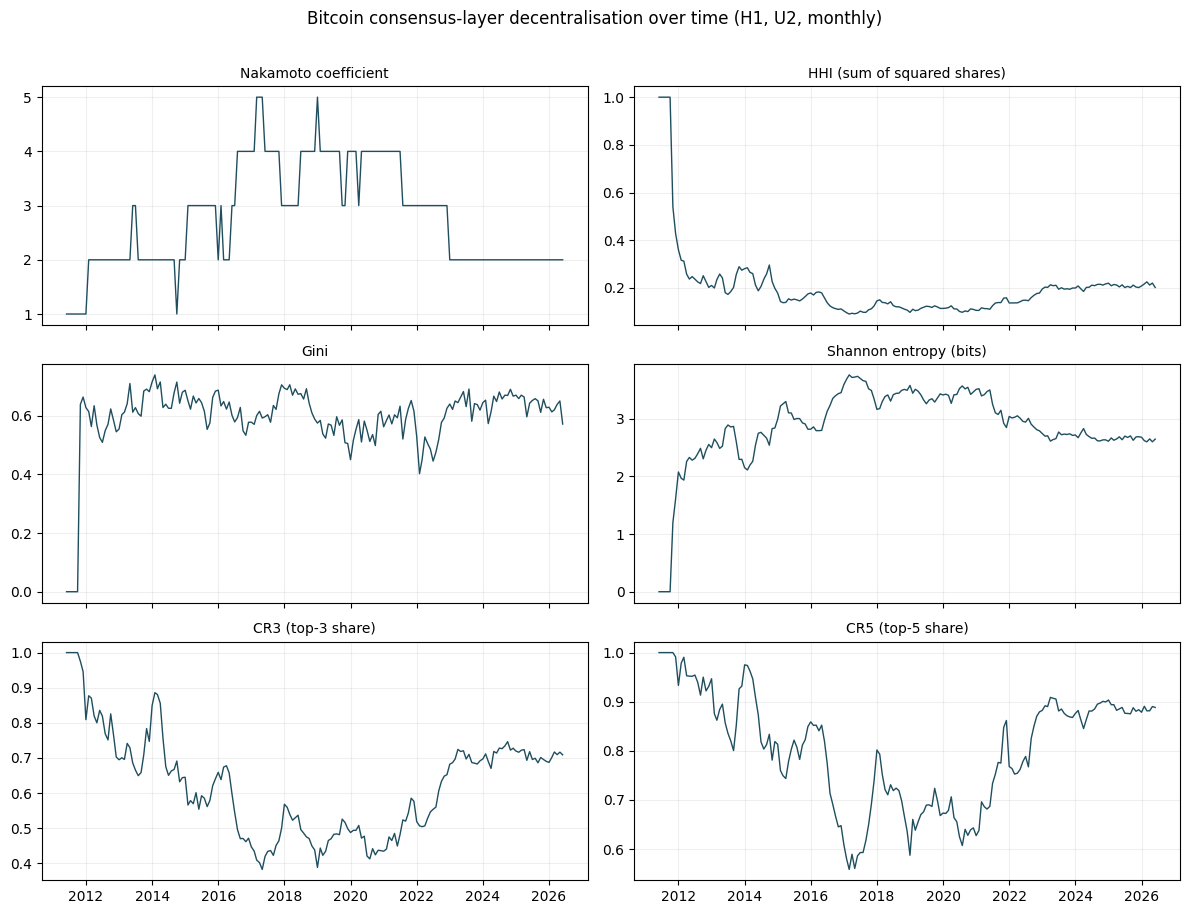

In [4]:
wide = mt.pivot(index="window", columns="metric", values="value")
panels = ["nakamoto", "hhi", "gini", "shannon", "cr3", "cr5"]
titles = {"nakamoto":"Nakamoto coefficient", "hhi":"HHI (sum of squared shares)",
          "gini":"Gini", "shannon":"Shannon entropy (bits)",
          "cr3":"CR3 (top-3 share)", "cr5":"CR5 (top-5 share)"}

fig, axes = plt.subplots(3, 2, figsize=(12, 9), sharex=True)
for ax, col in zip(axes.ravel(), panels):
    ax.plot(wide.index, wide[col], lw=1, color="#1f4e5f")
    ax.set_title(titles[col], fontsize=10)
    ax.grid(alpha=0.2)
fig.suptitle("Bitcoin consensus-layer decentralisation over time (H1, U2, monthly)", y=1.01)
fig.tight_layout()
import os
os.makedirs("../figures", exist_ok=True)
fig.savefig("../figures/metrics_over_time.png", dpi=120, bbox_inches="tight")
plt.show()